# LLC Results Causal Ablation

The paper used "Differentiation and Specialization of Attention Heads via the Refined Local Learning Coefficient". In the article they investigate the functional role of the head through the framework of Singular Learning Theory. I was interested in validating the causality of these findings with mech interp approaches.

The pipeline is as follows:
1. Load "attn-only-2l"
2. Build two synthetic test datasets:
   - induction: repeated random token sequences, testing [A][B] ... [A] -> [B]
   - bigram/multigram: repeated common phrase templates, testing memorized local phrase continuations
3. Zero-ablate each of the 16 heads.
4. Measure delta_loss for each task.

In [ ]:
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from transformer_lens import HookedTransformer

sns.set_theme(style="whitegrid", context="notebook")

<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


In [21]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cpu"

In [22]:
MODEL_NAME = "attn-only-2l"

SEQ_LEN = 64
N_INDUCTION_SEQS = 256
N_BIGRAM_SEQS = 256
BATCH_SIZE = 32

## 1. Load the model

In [23]:
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
model.eval()

N_LAYERS = model.cfg.n_layers
N_HEADS = model.cfg.n_heads
ALL_HEADS = [(layer, head) for layer in range(N_LAYERS) for head in range(N_HEADS)]

model

/usr/local/lib/python3.11/json/__init__.py:293: ResourceWarning: unclosed file <_io.TextIOWrapper name='/home/epifantsevst/.cache/huggingface/hub/models--NeelNanda--Attn_Only_2L512W_C4_Code/snapshots/4fb5f8490562081b69a0139e0469f36e88fdb160/./config.json' mode='r' encoding='UTF-8'>
  return loads(fp.read(),


Loaded pretrained model attn-only-2l into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_resid_pre): HookPoint()
      (hook_resid_post): HookPoint()
    )
  )
  (ln_final): LayerNormPre(
    (hook_scale): HookPoint()
    (hook_normalized): HookPoint()
  )
  (unembed): Unembed(
    (ho

## 2. Head Classification according to rLLC

The classification below is taken from the original paper

In [24]:
HEAD_TYPE = {
    "0:0": "Multigram",
    "0:1": "Previous-token",
    "0:2": "Multigram",
    "0:3": "Multigram",
    "0:4": "Previous-token",
    "0:5": "Current-token",
    "0:6": "Multigram",
    "0:7": "Multigram (Dyck)",
    "1:0": "Multigram",
    "1:1": "Multigram",
    "1:2": "Multigram",
    "1:3": "Multigram (Dyck)",
    "1:4": "Multigram",
    "1:5": "Multigram (Dyck)",
    "1:6": "Induction",
    "1:7": "Induction",
}

In [ ]:
def simplify_type(head_type: str) -> str:
    if head_type == "Induction":
        return "Induction"
    if "Multigram" in head_type:
        return "Multigram"
    return "Other"

HEAD_CLUSTER = {k: simplify_type(v) for k, v in HEAD_TYPE.items()}

CLUSTER_PALETTE = {
    "Induction": "#2A9D8F",
    "Multigram": "#E76F51",
    "Other": "#8D99AE",
}

head_table = pd.DataFrame({
    "head": [f"{l}:{h}" for l, h in ALL_HEADS],
    "paper_type": [HEAD_TYPE[f"{l}:{h}"] for l, h in ALL_HEADS],
    "paper_cluster": [HEAD_CLUSTER[f"{l}:{h}"] for l, h in ALL_HEADS],
})
head_table

,head,paper_type,paper_cluster
0,0:0,Multigram,Multigram
1,0:1,Previous-token,Other
2,0:2,Multigram,Multigram
3,0:3,Multigram,Multigram
4,0:4,Previous-token,Other
5,0:5,Current-token,Other
6,0:6,Multigram,Multigram
7,0:7,Multigram (Dyck),Multigram
8,1:0,Multigram,Multigram
9,1:1,Multigram,Multigram


## 3. Build synthetic datasets

### Induction task
The sequence has the form:

`prefix + prefix`

For positions in the second copy, the correct next token is recoverable from the earlier occurrence.  
This directly tests the induction pattern `[A][B] ... [A] -> [B]`.

### Multigram task
The sequence is built from repeated common phrase templates.  

In [25]:
@dataclass
class MaskedTokenDataset:
    tokens: torch.Tensor 
    loss_mask: torch.Tensor
    name: str


def make_induction_dataset(
    model,
    n_seqs: int = N_INDUCTION_SEQS,
    seq_len: int = SEQ_LEN,
    seed: int = SEED,
) -> MaskedTokenDataset:
    g = torch.Generator().manual_seed(seed)
    half = seq_len // 2

    prefix = torch.randint(
        low=100,
        high=min(model.cfg.d_vocab - 1, 20_000),
        size=(n_seqs, half),
        generator=g,
    )

    tokens = torch.cat([prefix, prefix], dim=1)
    tokens = tokens[:, :seq_len].long()

    loss_mask = torch.zeros((n_seqs, seq_len - 1), dtype=torch.bool)
    loss_mask[:, half:(seq_len - 1)] = True

    return MaskedTokenDataset(tokens=tokens, loss_mask=loss_mask, name="induction")

In [ ]:
COMMON_PHRASES = [
    "New York City is",
    "United States of America",
    "San Francisco Bay Area",
    "Los Angeles Times reported",
    "according to the report",
    "as a result of",
    "at the end of",
    "in the middle of",
    "on the other hand",
    "for the first time",
    "the same time as",
    "one of the most",
    "the University of California",
    "the New York Times",
    "President of the United States",
    "Department of Justice said",
    "in response to the",
    "the rest of the",
    "a member of the",
    "the beginning of the",
]


def make_bigram_dataset(
    model,
    n_seqs: int = N_BIGRAM_SEQS,
    seq_len: int = SEQ_LEN,
    seed: int = SEED,
) -> MaskedTokenDataset:
    """
    Builds sequences by concatenating common phrase templates.

    The loss mask focuses on non-BOS next-token predictions throughout the phrase-heavy text.
    This acts as a simple multigram / local phrase-continuation task.
    """
    rng = random.Random(seed)
    texts = []

    for _ in range(n_seqs):
        chunks = [rng.choice(COMMON_PHRASES) for _ in range(18)]
        text = ". ".join(chunks) + "."
        texts.append(text)

    toks = model.to_tokens(texts, prepend_bos=True)
    if toks.shape[1] < seq_len:
        pad_id = model.tokenizer.eos_token_id
        pad = torch.full((toks.shape[0], seq_len - toks.shape[1]), pad_id, dtype=toks.dtype)
        toks = torch.cat([toks, pad], dim=1)
    tokens = toks[:, :seq_len].long()

    loss_mask = torch.ones((tokens.shape[0], seq_len - 1), dtype=torch.bool)
    loss_mask[:, 0] = False

    if model.tokenizer.eos_token_id is not None:
        eos = model.tokenizer.eos_token_id
        loss_mask &= (tokens[:, 1:] != eos)

    return MaskedTokenDataset(tokens=tokens, loss_mask=loss_mask, name="bigram_multigram")

In [27]:
induction_ds = make_induction_dataset(model)
bigram_ds = make_bigram_dataset(model)

TASK_DATASETS = {
    "induction": induction_ds,
    "bigram_multigram": bigram_ds,
}

In [28]:
model.to_string(bigram_ds.tokens[0, :80])

'<|BOS|>Los Angeles Times reported. New York City is. on the other hand. in the middle of. in the middle of. according to the report. Los Angeles Times reported. the rest of the. San Francisco Bay Area. a member of the. the New York Times. United States of America. New York City'

In [30]:
model.to_string(induction_ds.tokens[0, :20])

' startuating north combinedwaphan Deputyreference went fortune exceptional amazrightONE Jeanamplesgest Zealand southern dimin'

In [39]:
model.to_string(induction_ds.tokens[0, 32:32 + 20])

' startuating north combinedwaphan Deputyreference went fortune exceptional amazrightONE Jeanamplesgest Zealand southern dimin'

## 4. Loss Baseline

In [ ]:
def masked_next_token_loss(
    model: HookedTransformer,
    tokens: torch.Tensor,
    loss_mask: torch.Tensor,
    batch_size: int = BATCH_SIZE,
    device: str = DEVICE,
    fwd_hooks=None,
) -> float:
    total_loss = 0.0
    total_count = 0

    model.eval()
    with torch.no_grad():
        for start in range(0, tokens.shape[0], batch_size):
            batch_tokens = tokens[start:start + batch_size].to(device)
            batch_mask = loss_mask[start:start + batch_size].to(device)

            if fwd_hooks is None:
                logits = model(batch_tokens, return_type="logits")
            else:
                logits = model.run_with_hooks(
                    batch_tokens,
                    return_type="logits",
                    fwd_hooks=fwd_hooks,
                )

            log_probs = F.log_softmax(logits[:, :-1, :], dim=-1)
            targets = batch_tokens[:, 1:]

            token_loss = -log_probs.gather(dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)
            token_loss = token_loss[batch_mask]

            total_loss += token_loss.sum().item()
            total_count += batch_mask.sum().item()

    return total_loss / max(total_count, 1)

In [13]:
baseline_losses = {}

for task_name, ds in TASK_DATASETS.items():
    loss = masked_next_token_loss(model, ds.tokens, ds.loss_mask)
    baseline_losses[task_name] = loss
    print(f"Baseline loss [{task_name}]: {loss:.4f}")

Baseline loss [induction]: 11.0303
Baseline loss [bigram_multigram]: 3.6377


## 5. Zero-ablate Attention Heads

For each head, we zero its `hook_z` output and recompute the masked loss.  

`delta_loss = loss_after_ablation - baseline_loss`

Positive `delta_loss means that ablating the head made the task harder.

In [ ]:
def make_zero_ablation_hook(head: int):
    def hook(value, hook):
        value[:, :, head, :] = 0.0
        return value
    return hook


def zero_ablate_head_loss(
    model: HookedTransformer,
    dataset: MaskedTokenDataset,
    layer: int,
    head: int,
    batch_size: int = BATCH_SIZE,
    device: str = DEVICE,
) -> float:
    hook_name = f"blocks.{layer}.attn.hook_z"
    fwd_hooks = [(hook_name, make_zero_ablation_hook(head))]

    return masked_next_token_loss(
        model=model,
        tokens=dataset.tokens,
        loss_mask=dataset.loss_mask,
        batch_size=batch_size,
        device=device,
        fwd_hooks=fwd_hooks,
    )

In [ ]:
ablation_rows = []

for layer, head in tqdm(ALL_HEADS):
    head_label = f"{layer}:{head}"

    row = {
        "head": head_label,
        "layer": layer,
        "head_index": head,
        "paper_type": HEAD_TYPE[head_label],
        "paper_cluster": HEAD_CLUSTER[head_label],
    }

    for task_name, ds in TASK_DATASETS.items():
        ablated_loss = zero_ablate_head_loss(model, ds, layer, head)
        delta = ablated_loss - baseline_losses[task_name]

        row[f"loss_{task_name}"] = ablated_loss
        row[f"delta_loss_{task_name}"] = delta

    ablation_rows.append(row)

df_ablation = pd.DataFrame(ablation_rows)
df_ablation

Zero-ablating heads:   0%|          | 0/16 [00:00<?, ?it/s]

,head,layer,head_index,paper_type,paper_cluster,loss_induction,delta_loss_induction,loss_bigram_multigram,delta_loss_bigram_multigram
0,0:0,0,0,Multigram,Multigram,13.257612,2.227300,4.103336,0.465621
1,0:1,0,1,Previous-token,Other,10.307635,-0.722677,3.663678,0.025963
2,0:2,0,2,Multigram,Multigram,11.156659,0.126347,5.756221,2.118506
3,0:3,0,3,Multigram,Multigram,15.125171,4.094859,4.724951,1.087236
4,0:4,0,4,Previous-token,Other,9.066868,-1.963444,5.905114,2.267399
5,0:5,0,5,Current-token,Other,10.414397,-0.615915,3.944125,0.306410
6,0:6,0,6,Multigram,Multigram,11.433031,0.402719,3.781569,0.143855
7,0:7,0,7,Multigram (Dyck),Multigram,10.402770,-0.627542,4.746074,1.108359
8,1:0,1,0,Multigram,Multigram,11.059281,0.028969,3.916270,0.278555
9,1:1,1,1,Multigram,Multigram,10.992660,-0.037652,3.528741,-0.108974


In [16]:
df_ablation.to_csv("induction_head_ablation_results.csv", index=False)
print("Saved induction_head_ablation_results.csv")

Saved induction_head_ablation_results.csv


## 6. Plot Results

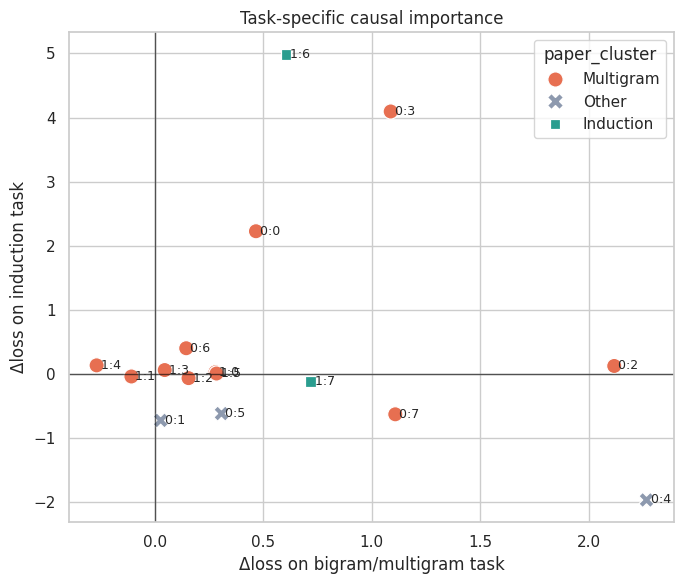

In [ ]:
plt.figure(figsize=(7, 6))

ax = sns.scatterplot(
    data=df_ablation,
    x="delta_loss_bigram_multigram",
    y="delta_loss_induction",
    hue="paper_cluster",
    style="paper_cluster",
    palette=CLUSTER_PALETTE,
    s=120,
)

for _, row in df_ablation.iterrows():
    ax.text(
        row["delta_loss_bigram_multigram"],
        row["delta_loss_induction"],
        " " + row["head"],
        fontsize=9,
        va="center",
    )

ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.axvline(0, color="black", linewidth=1, alpha=0.6)
ax.set_title("Task-specific causal importance")
ax.set_xlabel("delta_loss on bigram/multigram task")
ax.set_ylabel("delta_loss on induction task")
plt.tight_layout()
plt.show()